In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_contaminante = pd.read_csv('Monitoreo de los contaminantes del aire en Lima Metropolitana - [Servicio Nacional de Meteorología e Hidrología del Perú - SENAMHI]_1 (1).csv')
#Modificamos el formato de la hora
df_contaminante['HORA'] = pd.to_datetime(df_contaminante['HORA'].astype(str).str.zfill(6), format='%H%M%S').dt.time
#Modificamos el formato de la fecha
df_contaminante['FECHA'] = pd.to_datetime(df_contaminante['FECHA'], format='%Y%m%d')
#Creamos una columna que solo contenga el año para usarlo como merge
df_contaminante['Año'] = df_contaminante['FECHA'].dt.year
df_contaminante.rename(columns={'UBIGEO': 'Ubigeo'}, inplace=True)
df_contaminante['Ubigeo'] = df_contaminante['Ubigeo'].astype(int)
meses = {
    1: "ENERO", 2: "FEBRERO", 3: "MARZO", 4: "ABRIL",
    5: "MAYO", 6: "JUNIO", 7: "JULIO", 8: "AGOSTO",
    9: "SEPTIEMBRE", 10: "OCTUBRE", 11: "NOVIEMBRE", 12: "DICIEMBRE"
}
df_contaminante["MES"] = df_contaminante["FECHA"].dt.month.map(meses)
df_contaminante.info()
df_contaminante['DISTRITO'].unique()
df_contaminante.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577794 entries, 0 to 577793
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   ID            577794 non-null  int64         
 1   ESTACION      577794 non-null  object        
 2   FECHA         577794 non-null  datetime64[ns]
 3   HORA          577794 non-null  object        
 4   LONGITUD      577794 non-null  float64       
 5   LATITUD       577794 non-null  float64       
 6   ALTITUD       577794 non-null  float64       
 7   PM10          380982 non-null  float64       
 8   PM2_5         367591 non-null  float64       
 9   NO2           299192 non-null  float64       
 10  DEPARTAMENTO  577794 non-null  object        
 11  PROVINCIA     577794 non-null  object        
 12  DISTRITO      577794 non-null  object        
 13  Ubigeo        577794 non-null  int64         
 14  FECHA_CORTE   577794 non-null  int64         
 15  Año           577

,ID,ESTACION,FECHA,HORA,LONGITUD,LATITUD,ALTITUD,PM10,PM2_5,NO2,DEPARTAMENTO,PROVINCIA,DISTRITO,Ubigeo,FECHA_CORTE,Año,MES
0,1,CAMPO_DE_MARTE,2015-01-01,05:00:00,-77.0432,-12.0705,117.0,37.92,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113,20240531,2015,ENERO
1,2,CAMPO_DE_MARTE,2015-01-01,06:00:00,-77.0432,-12.0705,117.0,153.39,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113,20240531,2015,ENERO
2,3,CAMPO_DE_MARTE,2015-01-01,07:00:00,-77.0432,-12.0705,117.0,116.49,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113,20240531,2015,ENERO
3,4,CAMPO_DE_MARTE,2015-01-01,08:00:00,-77.0432,-12.0705,117.0,80.74,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113,20240531,2015,ENERO
4,5,CAMPO_DE_MARTE,2015-01-01,09:00:00,-77.0432,-12.0705,117.0,27.40,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113,20240531,2015,ENERO


In [ ]:
df_ira = pd.read_csv('datos_abiertos_vigilancia_iras_2000_2024 (1).csv', sep = ';',
                     header = None)
df_ira.columns = ['Departamento','Provincia','Distrito','Año','Semana','Sub_reg_nt',
    'Ubigeo','Ira_no_neumonia','Neumonía_<5años','Neumonía_>60 años',
'Hospitalizados_< 5 años','Hospitalizados_>60 años','Defunciones < 5años','Defunciones >60 años']
df_ira.head(10)

,Departamento,Provincia,Distrito,Año,Semana,Sub_reg_nt,Ubigeo,Ira_no_neumonia,Neumonía_<5años,Neumonía_>60 años,Hospitalizados_< 5 años,Hospitalizados_>60 años,Defunciones < 5años,Defunciones >60 años
0,CUSCO,ANTA,HUAROCONDO,2004,15,8,80305,6,0,0,0,0,0,0
1,ANCASH,SANTA,COISHCO,2006,5,2,21803,11,0,0,0,0,0,0
2,ANCASH,ANTONIO RAIMONDI,CHACCHO,2007,42,2,20303,7,0,0,0,0,0,0
3,ANCASH,HUARAZ,HUARAZ,2004,8,2,20101,90,0,0,0,0,0,0
4,LIMA,BARRANCA,SUPE,2009,43,42,150204,94,0,0,0,0,0,0
5,JUNIN,JAUJA,ATAURA,2002,5,12,120404,1,0,0,0,0,0,0
6,ANCASH,HUAYLAS,YURACMARCA,2003,5,2,21210,6,0,0,0,0,0,0
7,HUANCAVELICA,HUANCAVELICA,HUAYLLAHUARA,2004,9,9,90107,8,0,0,0,0,0,0
8,LAMBAYEQUE,LAMBAYEQUE,SALAS,2009,11,14,140310,42,0,0,0,0,0,0
9,LIMA,LIMA,CIENEGUILLA,2015,2,52,150109,42,0,0,0,0,0,0


In [ ]:
df_gente = pd.read_excel('3464927-anexo-1.xlsx', header=None) #cantidad de gente por distrito y provincia
df_gente = df_gente.iloc[1594:1643] #Quedarse con las filas de la provincia de Lima Metropolitana
df_gente.dropna(subset = 2, inplace = True) #Eliminar columnas de titulos
df_gente.drop(1622, inplace=True) #Eliminar una fila con el nombre de las columnas donde no debe
df_gente.columns = ['UBIGEO','DISTRITO','2018','2019',
                    '2020','2021','2022']
df_gente.info() #cambiar tipo de dato necesario
df_gente = df_gente.melt(
    id_vars=['UBIGEO', 'DISTRITO'], # Columnas que se mantienen fijas
    value_vars=['2018', '2019', '2020', '2021', '2022'], # Columnas a apilar
    var_name='Año', # Nombre de la nueva columna que contendrá los años
    value_name='Poblacion' # Nombre de la nueva columna con la cantidad de gente
)
# 2. Igualar los tipos de datos
# Convertimos el año que ahora es texto (ej. "2018") a número entero
df_gente['Año'] = df_gente['Año'].astype(int)

# Convertimos UBIGEO a número para que coincida con el float64 de df_contaminante
df_gente['UBIGEO'] = pd.to_numeric(df_gente['UBIGEO'], errors='coerce')

# Renombramos UBIGEO para que coincida exactamente con la capitalización de la otra tabla
df_gente.rename(columns={'UBIGEO': 'Ubigeo'}, inplace=True)
df_gente['Poblacion'] = df_gente['Poblacion'].astype(int)
df_gente.info()
df_gente

<class 'pandas.core.frame.DataFrame'>
Index: 43 entries, 1594 to 1641
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   UBIGEO    43 non-null     object 
 1   DISTRITO  43 non-null     object 
 2   2018      43 non-null     object 
 3   2019      43 non-null     object 
 4   2020      43 non-null     object 
 5   2021      43 non-null     float64
 6   2022      43 non-null     object 
dtypes: float64(1), object(6)
memory usage: 2.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Ubigeo     215 non-null    int64 
 1   DISTRITO   215 non-null    object
 2   Año        215 non-null    int64 
 3   Poblacion  215 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.8+ KB


,Ubigeo,DISTRITO,Año,Poblacion
0,150101,LIMA,2018,271324
1,150102,ANCÓN,2018,70294
2,150103,ATE,2018,633470
3,150104,BARRANCO,2018,35467
4,150105,BREÑA,2018,90920
...,...,...,...,...
210,150139,SANTA ROSA,2022,42107
211,150140,SANTIAGO DE SURCO,2022,420016
212,150141,SURQUILLO,2022,102434
213,150142,VILLA EL SALVADOR,2022,432170


In [ ]:
df_arboles24 = pd.read_csv('02-DISTRIBUCION DE ARBOLES POR DISTRITO - SERPAR LIMA_2701.csv', sep = ',')
df_arboles25 = pd.read_csv('02-DISTRIBUCION DE ARBOLES POR DISTRITO - SERPAR LIMA_2001.csv', sep = ',')
df_arboles26 = pd.read_csv('02-DISTRIBUCION DE ARBOLES POR DISTRITO - SERPAR LIMA_2003.csv', sep = ',')

df_arboles24.columns = df_arboles24.columns.str.strip()
df_arboles25.columns = df_arboles25.columns.str.strip()
df_arboles26.columns = df_arboles26.columns.str.strip()
# 3. Renombrar la columna en df_arboles24 (que es la que tiene "CENTRO POBLADO...")
df_arboles24 = df_arboles24.rename(columns={'CENTRO POBLADO SANTA MARÍA DE HUACHIPA': 'SANTA MARÍA DE HUACHIPA'})
# 4. Concatenar las tablas y rellenar vacíos iniciales
df_arboles = pd.concat([df_arboles24, df_arboles25, df_arboles26], ignore_index=True)
df_arboles.fillna("0", inplace=True)
# Identificamos las columnas que NO vamos a convertir a número
columnas_excluidas = ['ITEM', 'AÑO', 'MES']
# Filtramos para quedarnos solo con los distritos y el TOTAL
columnas_distritos = [col for col in df_arboles.columns if col not in columnas_excluidas]
for col in columnas_distritos:
    # Si la columna es de tipo texto (object), le quitamos las comas
    if df_arboles[col].dtype == object:
        df_arboles[col] = df_arboles[col].str.replace(',', '', regex=False)
    # Convertimos a número (los errores se vuelven NaN, los llenamos con 0, y pasamos a entero)
    df_arboles[col] = pd.to_numeric(df_arboles[col], errors='coerce').fillna(0).astype(int)

df_arboles['AÑO'] = df_arboles['AÑO'].astype(int)
columnas_id = ['AÑO', 'MES']
columnas_distritos = [col for col in df_arboles.columns if col not in columnas_id + ['ITEM', 'TOTAL']]

df_arboles = df_arboles.melt(
    id_vars=columnas_id,
    value_vars=columnas_distritos,
    var_name='DISTRITO',
    value_name='ARBOLES_PLANTADOS'
)

# 2. Normalizar la columna DISTRITO en la tabla de árboles
df_arboles['DISTRITO'] = (
    df_arboles['DISTRITO']
    .str.normalize('NFKD') # Separa los caracteres de sus tildes
    .str.encode('ascii', errors='ignore') # Elimina las tildes
    .str.decode('utf-8') # Lo devuelve a formato texto
    .str.replace(' - ', '_') # Para casos como 'LURIGANCHO - CHOSICA'
    .str.replace(' ', '_') # Convierte espacios a guiones bajos
    .str.upper()
)
df_arboles.rename(columns={'AÑO': 'Año'}, inplace=True)
df_arboles.head()

/tmp/ipykernel_1855/2439806553.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_arboles.fillna("0", inplace=True)


,Año,MES,DISTRITO,ARBOLES_PLANTADOS
0,2024,ENERO,ANCON,1070
1,2024,FEBRERO,ANCON,500
2,2024,MARZO,ANCON,0
3,2024,ABRIL,ANCON,100
4,2024,MAYO,ANCON,1000


In [ ]:
import numpy as np
#Combinar tablas
df_final1 = pd.merge(
    df_contaminante,
    df_gente[['Ubigeo', 'Año', 'Poblacion']],
    on=['Ubigeo', 'Año'],
    how='left'
)

df_final2 = pd.merge(df_final1,
    df_arboles,
    on=['DISTRITO', 'Año', 'MES'],
    how='left'
)

#Relleno de nulos en las variables Poblacion y ARBOLES_PLANTADOS según el distrito (además de aproximarlo al entero)
df_final2['Poblacion'] = df_final2['Poblacion'].fillna(df_final2.groupby(['DISTRITO'])['Poblacion'].transform('mean'))
df_final2['ARBOLES_PLANTADOS'] = df_final2['ARBOLES_PLANTADOS'].fillna(df_final2.groupby(['DISTRITO'])['ARBOLES_PLANTADOS'].transform('mean'))
df_final2['Poblacion'] = df_final2['Poblacion'].round()
df_final2['ARBOLES_PLANTADOS'] = df_final2['ARBOLES_PLANTADOS'].round()

df_final2.info()

#unimos la 3ra df--------------------
# Convertimos la semana epidemiológica a un número de mes aproximado
df_ira['Mes_Num'] = np.ceil(df_ira['Semana'] / 4.345).astype(int)

# Diccionario para que los nombres coincidan exactamente con tu df_final2
meses_dict = {1: "ENERO", 2: "FEBRERO", 3: "MARZO", 4: "ABRIL", 5: "MAYO", 6: "JUNIO",
              7: "JULIO", 8: "AGOSTO", 9: "SEPTIEMBRE", 10: "OCTUBRE", 11: "NOVIEMBRE", 12: "DICIEMBRE"}

df_ira['MES'] = df_ira['Mes_Num'].map(meses_dict)

# Agrupamos las IRAS por Ubigeo, Año y MES para tener totales mensuales
df_ira_mensual = df_ira.groupby(['Ubigeo', 'Año', 'MES']).agg({
    'Ira_no_neumonia': 'sum',
    'Neumonía_<5años': 'sum',
    'Neumonía_>60 años': 'sum'
}).reset_index()

df_aire_mensual = df_final2.groupby(['Ubigeo', 'Año', 'MES']).agg({
    'PM10': 'mean',
    'PM2_5': 'mean',
    'NO2': 'mean',
    'Poblacion': 'mean',
    'ARBOLES_PLANTADOS': 'sum'
}).reset_index()

# Unimos usando un 'inner join' para quedarnos solo con los meses/distritos que tienen ambas infos
df_final3 = pd.merge(
    df_aire_mensual,
    df_ira_mensual,
    on=['Ubigeo', 'Año', 'MES'],
    how='inner'
)

# Visualizamos el resultado
df_final3.info()
df_final3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577794 entries, 0 to 577793
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577794 non-null  int64         
 1   ESTACION           577794 non-null  object        
 2   FECHA              577794 non-null  datetime64[ns]
 3   HORA               577794 non-null  object        
 4   LONGITUD           577794 non-null  float64       
 5   LATITUD            577794 non-null  float64       
 6   ALTITUD            577794 non-null  float64       
 7   PM10               380982 non-null  float64       
 8   PM2_5              367591 non-null  float64       
 9   NO2                299192 non-null  float64       
 10  DEPARTAMENTO       577794 non-null  object        
 11  PROVINCIA          577794 non-null  object        
 12  DISTRITO           577794 non-null  object        
 13  Ubigeo             577794 non-null  int64   

,Ubigeo,Año,MES,PM10,PM2_5,NO2,Poblacion,ARBOLES_PLANTADOS,Ira_no_neumonia,Neumonía_<5años,Neumonía_>60 años
0,150106,2015,ABRIL,97.319569,31.805139,5.000000,395723.0,303840.0,1473,13,3
1,150106,2015,AGOSTO,72.180349,15.869012,21.477742,395723.0,313968.0,1105,1,1
2,150106,2015,DICIEMBRE,76.442436,25.838482,17.212050,395723.0,313968.0,1333,9,1
3,150106,2015,ENERO,74.337644,23.288843,NaN,395723.0,311858.0,1029,2,1
4,150106,2015,FEBRERO,85.968735,NaN,NaN,395723.0,283584.0,826,2,3
...,...,...,...,...,...,...,...,...,...,...,...
786,150143,2024,ABRIL,NaN,NaN,31.172083,437937.0,6480.0,1447,12,35
787,150143,2024,ENERO,29.329302,14.808827,22.075446,437937.0,0.0,1280,11,40
788,150143,2024,FEBRERO,33.759596,15.101629,21.996695,437937.0,0.0,947,12,30
789,150143,2024,MARZO,NaN,NaN,30.037446,437937.0,0.0,1719,13,48


In [ ]:
df_final2.shape

(46141, 19)

In [ ]:
df_final2.columns

Index(['ID', 'ESTACION', 'FECHA', 'HORA', 'LONGITUD', 'LATITUD', 'ALTITUD',
       'PM10', 'PM2_5', 'NO2', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO',
       'Ubigeo', 'FECHA_CORTE', 'Año', 'MES', 'Poblacion',
       'ARBOLES_PLANTADOS'],
      dtype='object')

In [ ]:
df_final2.dtypes


,0
ID,int64
ESTACION,object
FECHA,datetime64[ns]
HORA,object
LONGITUD,float64
LATITUD,float64
ALTITUD,float64
PM10,float64
PM2_5,float64
NO2,float64


In [ ]:
df_final2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46141 entries, 0 to 46140
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID                 46141 non-null  int64         
 1   ESTACION           46141 non-null  object        
 2   FECHA              46141 non-null  datetime64[ns]
 3   HORA               46141 non-null  object        
 4   LONGITUD           46141 non-null  float64       
 5   LATITUD            46141 non-null  float64       
 6   ALTITUD            46141 non-null  float64       
 7   PM10               41547 non-null  float64       
 8   PM2_5              37832 non-null  float64       
 9   NO2                19987 non-null  float64       
 10  DEPARTAMENTO       46141 non-null  object        
 11  PROVINCIA          46141 non-null  object        
 12  DISTRITO           46141 non-null  object        
 13  Ubigeo             46141 non-null  int64         
 14  FECHA_

In [ ]:
df_final2.select_dtypes(include='number').columns

Index(['ID', 'LONGITUD', 'LATITUD', 'ALTITUD', 'PM10', 'PM2_5', 'NO2',
       'Ubigeo', 'FECHA_CORTE', 'Año', 'Poblacion', 'ARBOLES_PLANTADOS'],
      dtype='object')

In [ ]:
df_final2.describe()

,ID,FECHA,LONGITUD,LATITUD,ALTITUD,PM10,PM2_5,NO2,Ubigeo,FECHA_CORTE,Año,Poblacion,ARBOLES_PLANTADOS
count,46141.000000,46141,4.614100e+04,4.614100e+04,46141.0,41547.000000,37832.000000,19987.000000,46141.0,4.614100e+04,46141.000000,19842.000000,0.0
mean,23071.000000,2017-08-18 23:30:00.507141376,-7.704320e+01,-1.207050e+01,117.0,33.533355,16.730008,21.241257,150113.0,2.024010e+07,2017.150669,79836.655881,NaN
min,1.000000,2015-01-01 00:00:00,-7.704320e+01,-1.207050e+01,117.0,5.070000,3.000000,0.000000,150113.0,2.024050e+05,2015.000000,78791.000000,NaN
25%,11536.000000,2016-04-25 00:00:00,-7.704320e+01,-1.207050e+01,117.0,21.500000,10.500000,9.500000,150113.0,2.024053e+07,2016.000000,78791.000000,NaN
50%,23071.000000,2017-08-19 00:00:00,-7.704320e+01,-1.207050e+01,117.0,29.790000,14.500000,16.900000,150113.0,2.024053e+07,2017.000000,80377.000000,NaN
75%,34606.000000,2018-12-13 00:00:00,-7.704320e+01,-1.207050e+01,117.0,41.210000,20.300000,28.100000,150113.0,2.024053e+07,2018.000000,80377.000000,NaN
max,46141.000000,2020-04-06 00:00:00,-7.704320e+01,-1.207050e+01,117.0,259.000000,98.700000,162.100000,150113.0,2.024053e+07,2020.000000,81743.000000,NaN
std,13319.903722,NaN,5.886200e-11,1.041312e-11,0.0,17.443146,9.408834,17.892378,0.0,9.328538e+04,1.526067,1018.312122,NaN


/tmp/ipykernel_14621/3908979717.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_final2["Hora_num"] = pd.to_datetime(


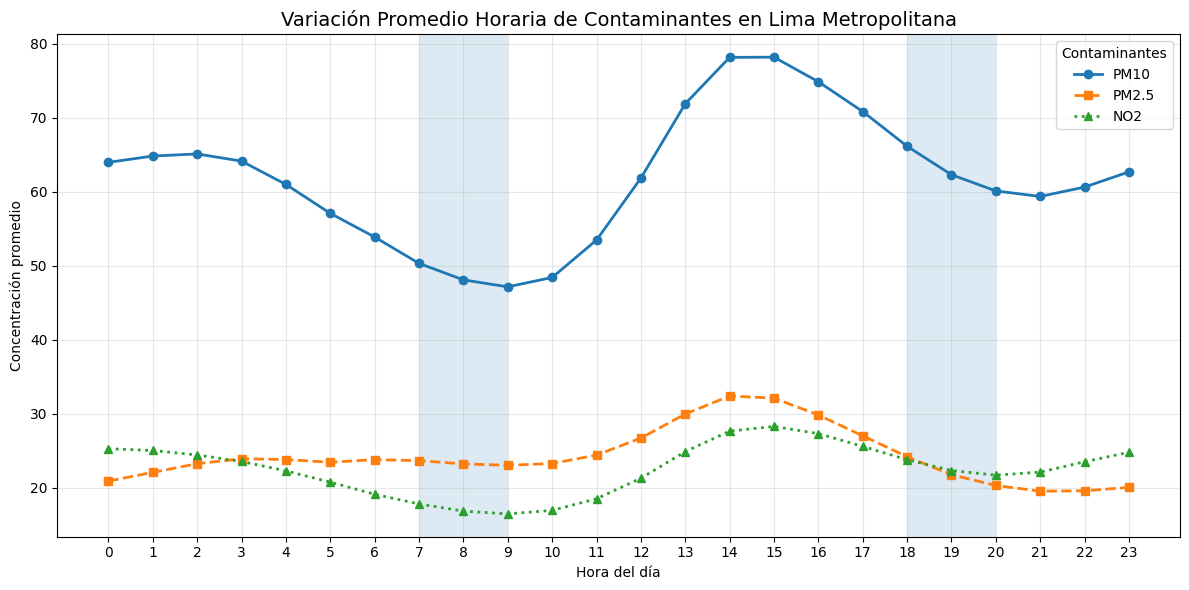

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear hora numérica
df_final2["Hora_num"] = pd.to_datetime(
    df_final2["HORA"].astype(str)
).dt.hour

# Promedio por hora
cont_hora = df_final2.groupby("Hora_num")[["PM10","PM2_5","NO2"]].mean()

plt.figure(figsize=(12,6))

plt.plot(
    cont_hora.index,
    cont_hora["PM10"],
    marker='o',
    linestyle='-',
    linewidth=2,
    label='PM10'
)

plt.plot(
    cont_hora.index,
    cont_hora["PM2_5"],
    marker='s',
    linestyle='--',
    linewidth=2,
    label='PM2.5'
)

plt.plot(
    cont_hora.index,
    cont_hora["NO2"],
    marker='^',
    linestyle=':',
    linewidth=2,
    label='NO2'
)

plt.title(
'Variación Promedio Horaria de Contaminantes en Lima Metropolitana',
fontsize=14
)

plt.xlabel('Hora del día')
plt.ylabel('Concentración promedio')

plt.xticks(range(0,24))
plt.grid(True, alpha=0.3)

plt.axvspan(7,9, alpha=0.15)
plt.axvspan(18,20, alpha=0.15)

plt.legend(
title='Contaminantes',
loc='upper right'
)

plt.tight_layout()
plt.show()

In [ ]:
df_final2[['PM10','PM2_5','NO2']].describe()

,PM10,PM2_5,NO2
count,380982.000000,367591.000000,299192.000000
mean,61.835134,24.253347,22.532890
std,46.535486,15.813837,14.979673
min,2.310000,1.730000,0.000000
25%,30.980000,13.700000,12.000000
50%,49.840000,20.300000,19.800000
75%,79.070000,30.470000,29.600000
max,974.000000,720.700000,231.200000


In [ ]:
(df_final2[['PM10','PM2_5','NO2']] < 0).sum()

,0
PM10,0
PM2_5,0
NO2,0


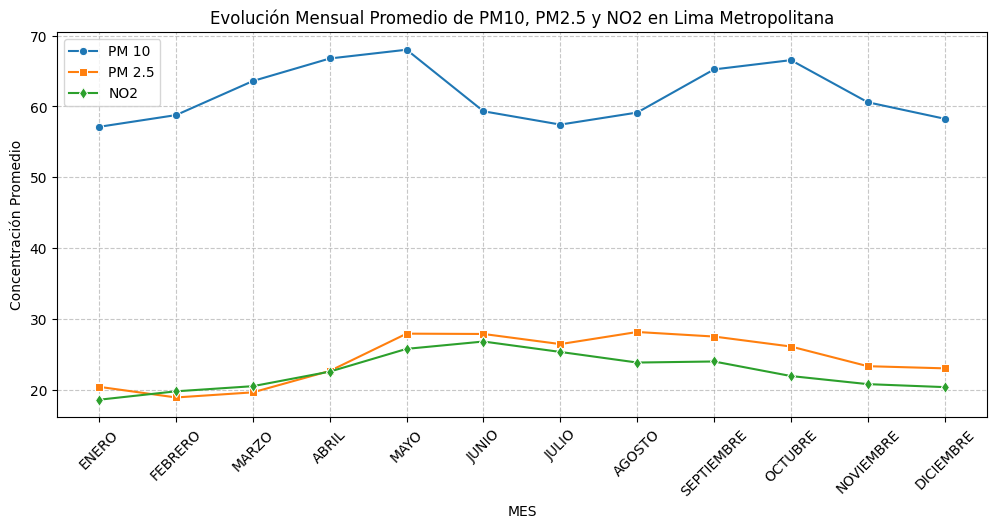

In [ ]:
#GRÁFICO EVOLUCIÓN MENSUAL DE CADA COMPONENTE DE CONTAMINACIÓN
# Definimos el orden correcto de los meses para el gráfico
plt.figure(figsize=(12, 5))
# Graficamos PM10, PM2.5 y NO2 a lo largo de los meses
sns.lineplot(data=df_final2, x='MES', y='PM10', label='PM 10', marker='o', errorbar=None)
sns.lineplot(data=df_final2, x='MES', y='PM2_5', label='PM 2.5', marker='s', errorbar=None)
sns.lineplot(data=df_final2, x='MES', y='NO2', label='NO2', marker='d', errorbar=None)
plt.title('Evolución Mensual Promedio de PM10, PM2.5 y NO2 en Lima Metropolitana')
plt.xticks(rotation=45)
plt.ylabel('Concentración Promedio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

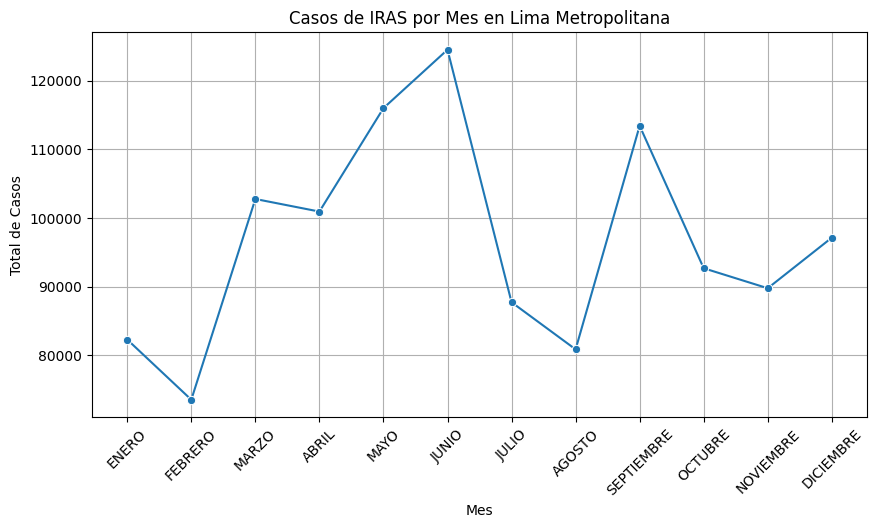

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Agrupamos sumando solo por 'MES'
df_meses = df_final3.groupby('MES')['Ira_no_neumonia'].sum().reset_index()

# 2. Le indicamos a Pandas el orden cronológico correcto
orden_meses = ["ENERO", "FEBRERO", "MARZO", "ABRIL", "MAYO", "JUNIO",
               "JULIO", "AGOSTO", "SEPTIEMBRE", "OCTUBRE", "NOVIEMBRE", "DICIEMBRE"]

# 3. Aplicamos el orden
df_meses['MES'] = pd.Categorical(df_meses['MES'], categories=orden_meses, ordered=True)
df_meses = df_meses.sort_values('MES')

# 4. Gráfico de líneas simple y directo
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_meses, x='MES', y='Ira_no_neumonia', marker='o')

plt.title('Casos de IRAS por Mes en Lima Metropolitana')
plt.xlabel('Mes')
plt.ylabel('Total de Casos')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

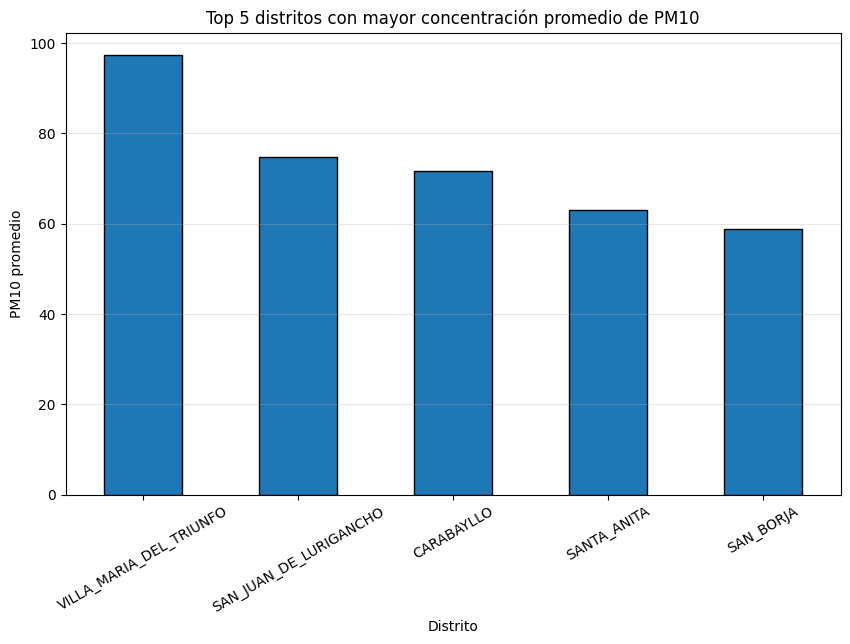

In [ ]:
import matplotlib.pyplot as plt

# Top 5 distritos con mayor PM10 promedio
top5_pm10 = (
    df_final2.groupby('DISTRITO')['PM10']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,6))

top5_pm10.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Top 5 distritos con mayor concentración promedio de PM10')
plt.xlabel('Distrito')
plt.ylabel('PM10 promedio')
plt.xticks(rotation=30)

plt.grid(axis='y', alpha=0.3)

plt.show()

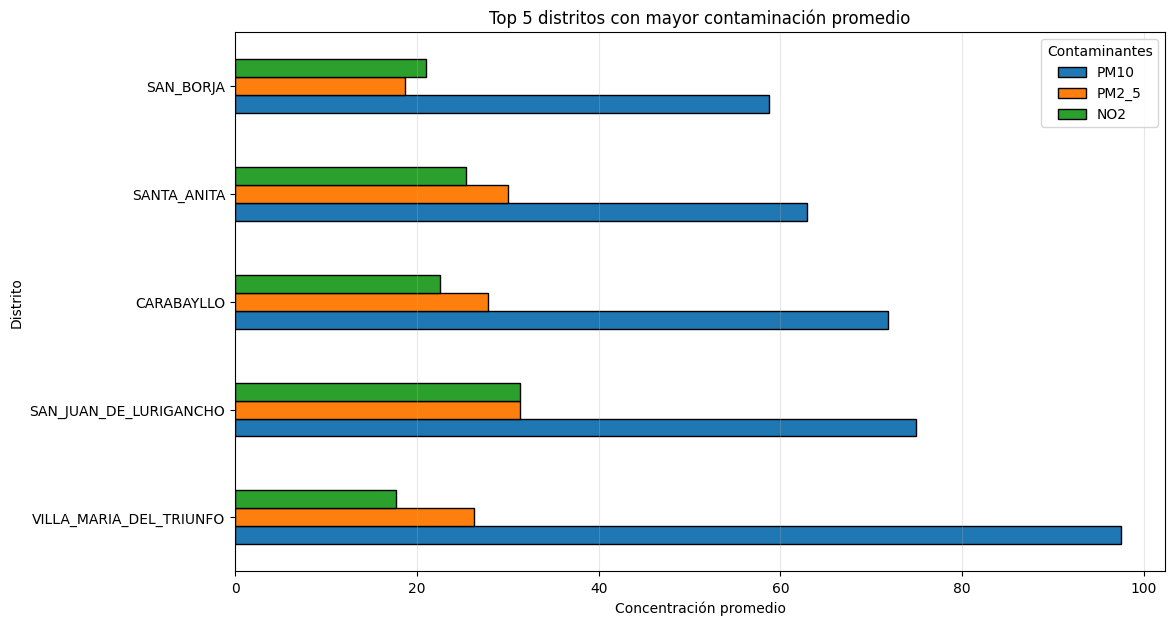

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Promedio por distrito
cont_df = df_final2.groupby('DISTRITO')[
['PM10','PM2_5','NO2']
].mean()

# Top 5 según PM10
top5 = cont_df.sort_values(
by='PM10',
ascending=False
).head(5)

# Gráfico
top5.plot(
kind='barh',
figsize=(12,7),
edgecolor='black'
)

plt.title('Top 5 distritos con mayor contaminación promedio')
plt.xlabel('Concentración promedio')
plt.ylabel('Distrito')

plt.legend(
title='Contaminantes'
)

plt.grid(axis='x', alpha=0.3)

plt.show()


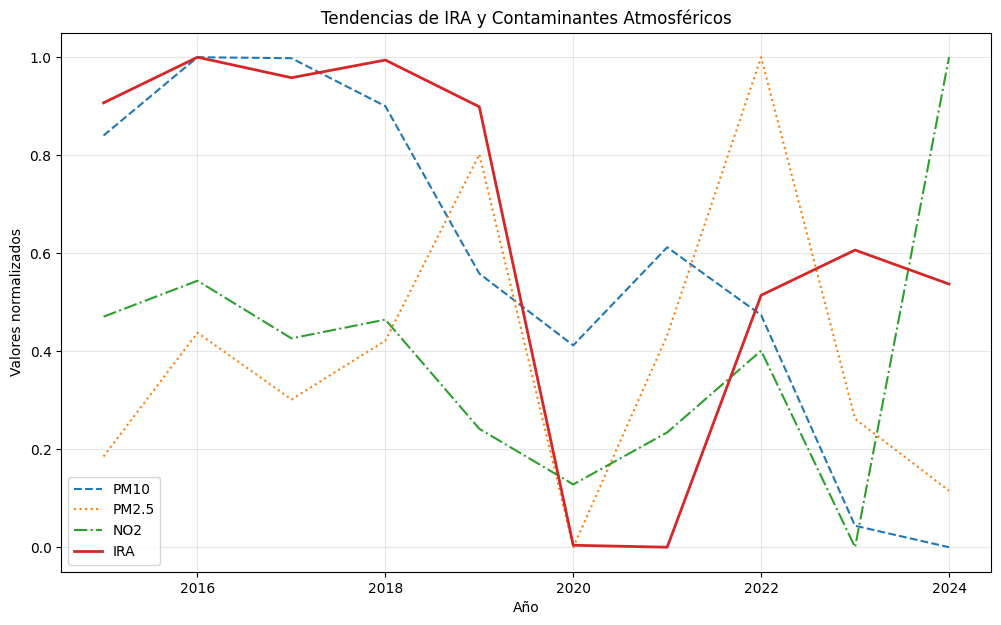

In [ ]:
import matplotlib.pyplot as plt

# Promedio por año
df_plot = df_final3.groupby('Año')[
['PM10','PM2_5','NO2','Ira_no_neumonia']
].mean()

# Normalizar para comparar tendencias
df_norm = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min())

plt.figure(figsize=(12,7))

plt.plot(
df_norm.index,
df_norm['PM10'],
label='PM10',
linestyle='--'
)

plt.plot(
df_norm.index,
df_norm['PM2_5'],
label='PM2.5',
linestyle=':'
)

plt.plot(
df_norm.index,
df_norm['NO2'],
label='NO2',
linestyle='-.'
)

plt.plot(
df_norm.index,
df_norm['Ira_no_neumonia'],
label='IRA',
linewidth=2
)

plt.title('Tendencias de IRA y Contaminantes Atmosféricos')
plt.xlabel('Año')
plt.ylabel('Valores normalizados')

plt.legend()
plt.grid(alpha=0.3)

plt.show()